In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier

In [2]:
raw_csv_path = 'data/raw/cybersecurity.csv'
df_raw = pd.read_csv(raw_csv_path)
train_df, test_df = train_test_split(df_raw, test_size=0.2, random_state=42)

In [3]:
def print_df_info(df):
    print("=" * 50)
    print(f"Shape: {df.shape}")
    print("=" * 50)
    print("Columns:")
    print(df.columns.tolist())
    print("=" * 50)
    print("Statistical description:")
    print(df.describe())
    print("=" * 50)
    print("First 5 rows:")
    print(df.head(5))
    print("=" * 50)
    print("Last 5 rows:")
    print(df.tail(5))
    print("=" * 50)
    print("amount of unique values:")
    print(df.nunique())
    print("=" * 50)

In [4]:
print_df_info(train_df)

Shape: (8000, 13)
Columns:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']
Statistical description:
           src_port      dst_port    bytes_sent  bytes_received        label
count   8000.000000   8000.000000  8.000000e+03    8.000000e+03  8000.000000
mean   27288.774875   2004.768625  1.490819e+05    2.858991e+05     0.039875
std    21025.362018   6664.840242  2.255905e+06    4.201067e+06     0.195678
min       21.000000      5.000000  1.700000e+01    3.000000e+00     0.000000
25%     6295.500000     25.000000  7.195000e+03    1.111675e+04     0.000000
50%    25877.000000    443.000000  2.181550e+04    3.785350e+04     0.000000
75%    45552.500000   1433.000000  6.497425e+04    1.223902e+05     0.000000
max    65524.000000  65491.000000  1.391704e+08    2.914830e+08     1.000000
First 5 rows:
                timestamp           src_ip         dst_ip  src_port  ds

In [5]:
print_df_info(test_df)

Shape: (2000, 13)
Columns:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']
Statistical description:
           src_port      dst_port    bytes_sent  bytes_received        label
count   2000.000000   2000.000000  2.000000e+03    2.000000e+03  2000.000000
mean   26106.019000   2117.328000  1.099585e+05    1.668450e+05     0.040500
std    20769.713597   7172.229673  1.512836e+06    6.101969e+05     0.197178
min       21.000000     21.000000  8.200000e+01    3.000000e+01     0.000000
25%     5548.500000     25.000000  6.935750e+03    1.046875e+04     0.000000
50%    23686.500000    443.000000  2.180900e+04    3.585650e+04     0.000000
75%    44284.750000   1433.000000  6.626325e+04    1.155542e+05     0.000000
max    65429.000000  65416.000000  6.711776e+07    1.323602e+07     1.000000
First 5 rows:
                timestamp          src_ip          dst_ip  src_port  ds

In [6]:
def analyze_missing(df):
    missing = df.isnull().sum()
    missing_percent = 100 * missing / len(df)
    missing_df = pd.DataFrame({
        'Column': df.columns,
        'Missing' : missing.values,
        'Percent' : missing_percent.values,
        'Dtype': df.dtypes.values
    })
    missing_df = missing_df[missing_df['Missing'] > 0]
    if len(missing_df) == 0:
        print("No missing values in dataset")
    else:
        print(missing_df.to_string(index=False))

In [7]:
analyze_missing(train_df)

Column  Missing  Percent Dtype
   url     2579  32.2375   str


In [8]:
analyze_missing(test_df)

Column  Missing  Percent Dtype
   url      653    32.65   str


In [9]:
def clean_df(df):
    print("Cleaning dataset")
    print("="*50)

    #Removing duplicates
    if df.duplicated().sum() > 0:
        dup_count = df.duplicated().sum()
        df = df.drop_duplicates()
        print(f"Removed {dup_count} duplicate rows \n")

    #Handle missing values
    if df.isnull().sum().sum() > 0:
        print("Handling missing values")
        print("=" * 50)
        if df['url'].isnull().any():
            df['url'] = df['url'].fillna('')
            print("url: Filled with empty string")
    else:
        print("No missing values detected - data is already clean!\n")
    final_missing = df.isnull().sum().sum()
    print(f"Missing values: {final_missing}")

In [10]:
clean_df(train_df)
clean_df(test_df)

Cleaning dataset
Handling missing values
url: Filled with empty string
Missing values: 0
Cleaning dataset
Handling missing values
url: Filled with empty string
Missing values: 0


In [11]:
def data_normalization(train_df, test_df):
    print("\n" + "=" * 50)
    print("Data normalization")
    print("=" * 50)

    train = train_df.copy()
    test = test_df.copy()

    print("\n Processing timestamp")
    for df in [train, test]:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df["hour"] = df["timestamp"].dt.hour
        df["day"] = df["timestamp"].dt.day
        df["month"] = df["timestamp"].dt.month
        df["dayofweek"] = df["timestamp"].dt.dayofweek
        df.drop("timestamp", axis=1, inplace=True)

    print("\n Normalizing bytes (StandardScaler)")
    scaler_bytes = StandardScaler()

    train[["bytes_sent", "bytes_received"]] = scaler_bytes.fit_transform(train[["bytes_sent", "bytes_received"]])

    test[["bytes_sent", "bytes_received"]] = scaler_bytes.transform(test[["bytes_sent", "bytes_received"]])

    print(f"Train mean: {train[['bytes_sent', 'bytes_received']].mean().values}")
    print(f"Test mean: {test[['bytes_sent', 'bytes_received']].mean().values}")

    print("\n Normalizing ports and time features (MinMaxScaler)")
    features_to_scale = ["src_port", "dst_port", "hour", "day", "month", "dayofweek"]

    scaler_ports = MinMaxScaler()

    train[features_to_scale] = scaler_ports.fit_transform(train[features_to_scale])
    test[features_to_scale] = scaler_ports.transform(test[features_to_scale])

    print("\n" + "=" * 50)
    print("Normalization completed!")

    return train, test

In [12]:
train_df, test_df = data_normalization(train_df, test_df)


Data normalization

 Processing timestamp

 Normalizing bytes (StandardScaler)
Train mean: [1.33226763e-18 1.99840144e-18]
Test mean: [-0.01734377 -0.02834079]

 Normalizing ports and time features (MinMaxScaler)

Normalization completed!


In [13]:
def encoding(train_df, test_df):
    print("\n" + "=" * 50)
    print("Data encoding")
    print("=" * 50)

    train = train_df.copy()
    test = test_df.copy()
    print("\n Protocol encoding:")

    protocol_dummies_train = pd.get_dummies(train["protocol"], prefix="protocol")
    protocol_dummies_test = pd.get_dummies(test["protocol"], prefix="protocol")

    train = pd.concat([train, protocol_dummies_train], axis=1)
    test = pd.concat([test, protocol_dummies_test], axis=1)
    train.drop("protocol", axis=1, inplace=True)
    test.drop("protocol", axis=1, inplace=True)

    print(f"Train columns: {list(protocol_dummies_train.columns)}")
    print(f"Test columns: {list(protocol_dummies_test.columns)}")

    print("\n Attack type encoding:")
    le_attack = LabelEncoder()
    train["attack_type"] = le_attack.fit_transform(train["attack_type"])
    test["attack_type"] = le_attack.transform(test["attack_type"])
    print(
        f"Mapping: {dict(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)))}"
    )

    if "url" in train.columns:
        print("\n URL encoding:")
        all_urls = pd.concat([train["url"], test["url"]]).unique()
        le_url = LabelEncoder()
        le_url.fit(all_urls)

        train["url"] = train["url"].fillna("unknown")
        test["url"] = test["url"].fillna("unknown")

        train["url_encoded"] = le_url.transform(train["url"])
        test["url_encoded"] = le_url.transform(test["url"])

        train.drop("url", axis=1, inplace=True)
        test.drop("url", axis=1, inplace=True)

        print(f" Unique URLs in train: {train['url_encoded'].nunique()}")
        print(f" Unique URLs in test: {test['url_encoded'].nunique()}")

    if "user_agent" in train.columns:
        print("\n User agent encoding:")
        all_agents = pd.concat([train["user_agent"], test["user_agent"]]).unique()
        le_ua = LabelEncoder()
        le_ua.fit(all_agents)

        train["user_agent"] = train["user_agent"].fillna("unknown")
        test["user_agent"] = test["user_agent"].fillna("unknown")

        train["user_agent_encoded"] = le_ua.transform(train["user_agent"])
        test["user_agent_encoded"] = le_ua.transform(test["user_agent"])

        train.drop("user_agent", axis=1, inplace=True)
        test.drop("user_agent", axis=1, inplace=True)

        print(f"Unique agents in train: {train['user_agent_encoded'].nunique()}")
        print(f"Unique agents in test: {test['user_agent_encoded'].nunique()}")

    if "is_internal_traffic" in train.columns:
        train["is_internal_traffic"] = train["is_internal_traffic"].astype(int)
        test["is_internal_traffic"] = test["is_internal_traffic"].astype(int)

    def ip_to_octets(ip):
        return [int(x) for x in ip.split(".")]

    oct_cols = ["oct1", "oct2", "oct3", "oct4"]

    train_src = train["src_ip"].apply(lambda x: pd.Series(ip_to_octets(x)))
    train_src.columns = [f"src_{c}" for c in oct_cols]
    train_dst = train["dst_ip"].apply(lambda x: pd.Series(ip_to_octets(x)))
    train_dst.columns = [f"dst_{c}" for c in oct_cols]

    train = pd.concat([train, train_src, train_dst], axis=1)
    train.drop(["src_ip", "dst_ip"], axis=1, inplace=True)

    test_src = test["src_ip"].apply(lambda x: pd.Series(ip_to_octets(x)))
    test_src.columns = [f"src_{c}" for c in oct_cols]
    test_dst = test["dst_ip"].apply(lambda x: pd.Series(ip_to_octets(x)))
    test_dst.columns = [f"dst_{c}" for c in oct_cols]

    test = pd.concat([test, test_src, test_dst], axis=1)
    test.drop(["src_ip", "dst_ip"], axis=1, inplace=True)
    
    # Нормализуем новые признаки
    ip_features = [
        "src_oct1",
        "src_oct2",
        "src_oct3",
        "src_oct4",
        "dst_oct1",
        "dst_oct2",
        "dst_oct3",
        "dst_oct4",
    ]

    scaler_ip = MinMaxScaler()
    train[ip_features] = scaler_ip.fit_transform(train[ip_features])
    test[ip_features] = scaler_ip.transform(test[ip_features])
    
    print("\n" + "=" * 50)
    print("Encoding completed!")
    print("=" * 50)
    print(f"\nTrain shape: {train.shape}")
    print(f"Test shape: {test.shape}")
    print(f"\nTrain columns: {list(train.columns)}")
    print(f"Test columns: {list(test.columns)}")
    return train, test

In [14]:
train_df, test_df = encoding(train_df, test_df)


Data encoding

 Protocol encoding:
Train columns: ['protocol_ICMP', 'protocol_TCP', 'protocol_UDP']
Test columns: ['protocol_ICMP', 'protocol_TCP', 'protocol_UDP']

 Attack type encoding:
Mapping: {'benign': np.int64(0), 'brute-force': np.int64(1), 'c2': np.int64(2), 'command-injection': np.int64(3), 'credential-stuffing': np.int64(4), 'ddos': np.int64(5), 'exploit-attempt': np.int64(6), 'port-scan': np.int64(7), 'sql-injection': np.int64(8), 'xss': np.int64(9)}

 URL encoding:
 Unique URLs in train: 5422
 Unique URLs in test: 1348

 User agent encoding:
Unique agents in train: 13
Unique agents in test: 13

Encoding completed!

Train shape: (8000, 24)
Test shape: (2000, 24)

Train columns: ['src_port', 'dst_port', 'bytes_sent', 'bytes_received', 'is_internal_traffic', 'label', 'attack_type', 'hour', 'day', 'month', 'dayofweek', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP', 'url_encoded', 'user_agent_encoded', 'src_oct1', 'src_oct2', 'src_oct3', 'src_oct4', 'dst_oct1', 'dst_oct2', '

In [15]:
print_df_info(train_df)

Shape: (8000, 24)
Columns:
['src_port', 'dst_port', 'bytes_sent', 'bytes_received', 'is_internal_traffic', 'label', 'attack_type', 'hour', 'day', 'month', 'dayofweek', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP', 'url_encoded', 'user_agent_encoded', 'src_oct1', 'src_oct2', 'src_oct3', 'src_oct4', 'dst_oct1', 'dst_oct2', 'dst_oct3', 'dst_oct4']
Statistical description:
          src_port     dst_port    bytes_sent  bytes_received  \
count  8000.000000  8000.000000  8.000000e+03    8.000000e+03   
mean      0.416283     0.030537  1.332268e-18    1.998401e-18   
std       0.320983     0.101775  1.000063e+00    1.000063e+00   
min       0.000000     0.000000 -6.608181e-02   -6.805746e-02   
25%       0.095790     0.000305 -6.289974e-02   -6.541183e-02   
50%       0.394730     0.006688 -5.641834e-02   -5.904716e-02   
75%       0.695106     0.021806 -3.728568e-02   -3.892322e-02   
max       1.000000     1.000000  6.162939e+01    6.931936e+01   

       is_internal_traffic        label

In [16]:
# 16% for validation
X = train_df.drop(['label', 'attack_type', 'bytes_sent'], axis = 1)
y_reg_train = train_df['bytes_sent']
y_clf_train = train_df['label']
X_test = test_df.drop(['label', 'attack_type', 'bytes_sent'], axis = 1)
y_reg_test = test_df['bytes_sent']
y_clf_test = test_df['label']
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(X, y_reg_train, y_clf_train, test_size = 0.2, random_state = 42)
print(X_train.shape, X_val.shape, X_test.shape)

(6400, 21) (1600, 21) (2000, 21)


In [17]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_reg_train)
y_pred_reg = linear_model.predict(X_test)

mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = root_mean_squared_error(y_reg_test, y_pred_reg)
mae = mean_absolute_error(y_reg_test, y_pred_reg)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

# comparing with naive model
mean_value = y_reg_train.mean() 
y_naive = np.full_like(y_reg_test, mean_value)
naive_mae = mean_squared_error(y_reg_test, y_naive)
print("MSE of naive model:", naive_mae)

MSE: 0.3624329895212344
RMSE: 0.6020240771939561
MAE: 0.038910690741079036
MSE of naive model: 0.44981586747552954


In [18]:
clf_model = LogisticRegression(max_iter = 1000, class_weight='balanced')
clf_model.fit(X_train, y_clf_train)
y_pred_clf = clf_model.predict(X_test)

accuracy = accuracy_score(y_clf_test, y_pred_clf)
precision = precision_score(y_clf_test, y_pred_clf)
recall = recall_score(y_clf_test, y_pred_clf)
f1 = f1_score(y_clf_test, y_pred_clf)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Classification report:\n")
print(classification_report(y_clf_test, y_pred_clf))

Accuracy: 0.6545
Precision: 0.06051873198847262
Recall: 0.5185185185185185
F1: 0.10838709677419354
Classification report:

              precision    recall  f1-score   support

           0       0.97      0.66      0.79      1919
           1       0.06      0.52      0.11        81

    accuracy                           0.65      2000
   macro avg       0.52      0.59      0.45      2000
weighted avg       0.93      0.65      0.76      2000



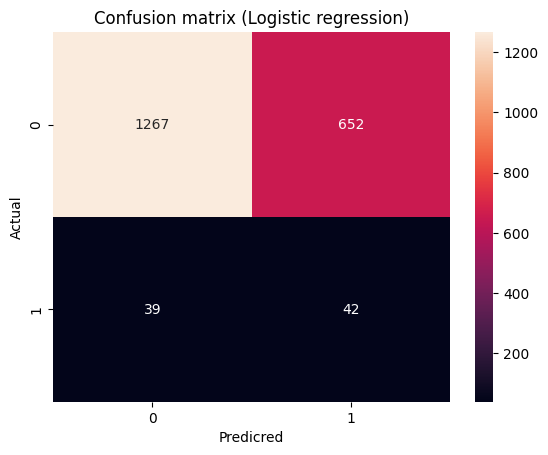

In [19]:
cm = confusion_matrix(y_clf_test, y_pred_clf)

plt.figure()
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion matrix (Logistic regression)")
plt.xlabel("Predicred")
plt.ylabel("Actual")
plt.show()

In [20]:
clf_tree = DecisionTreeClassifier(
    max_depth=8, min_samples_split=10, random_state=42, class_weight="balanced"
)
clf_tree.fit(X_train, y_clf_train)
y_pred_tree = clf_tree.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_clf_test, y_pred_tree))
print("Precision:", precision_score(y_clf_test, y_pred_tree))
print("Recall:", recall_score(y_clf_test, y_pred_tree))
print("F1:", f1_score(y_clf_test, y_pred_tree))
print("Classification report:\n")
print(classification_report(y_clf_test, y_pred_tree))

Accuracy: 0.833
Precision: 0.1553133514986376
Recall: 0.7037037037037037
F1: 0.2544642857142857
Classification report:

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1919
           1       0.16      0.70      0.25        81

    accuracy                           0.83      2000
   macro avg       0.57      0.77      0.58      2000
weighted avg       0.95      0.83      0.88      2000



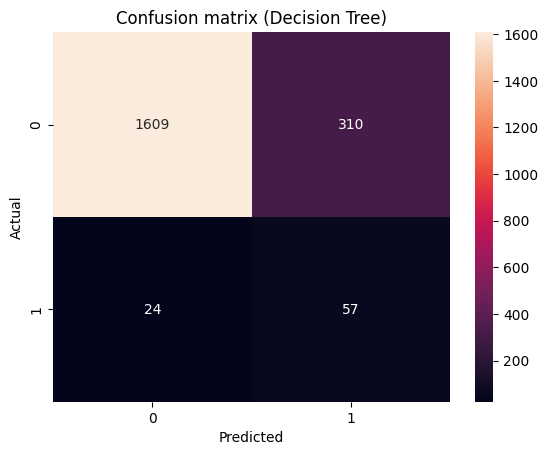

In [22]:
cm = confusion_matrix(y_clf_test, y_pred_tree)
plt.figure()
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion matrix (Decision Tree)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

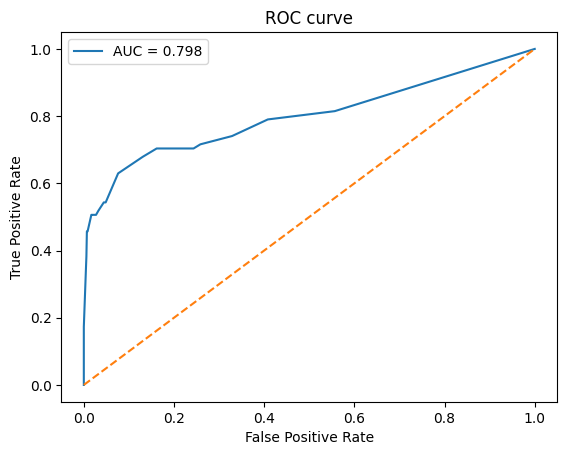

AUC: 0.7983356815213685


In [23]:
y_proba = clf_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0, 1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Decision Tree)")
plt.title('ROC curve')
plt.legend()
plt.show()
print("AUC:", roc_auc)

In [24]:
reg_tree = DecisionTreeRegressor(
    max_depth=8, min_samples_split=10, random_state=42
)
reg_tree.fit(X_train, y_reg_train)
y_pred_reg_tree = reg_tree.predict(X_test)

In [25]:
mse = mean_squared_error(y_reg_test, y_pred_reg_tree)
rmse = root_mean_squared_error(y_reg_test, y_pred_reg_tree)
mae = mean_absolute_error(y_reg_test, y_pred_reg_tree)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.38251134103498036
RMSE: 0.6184750124580461
MAE: 0.03268121600478734


In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_clf_train)
y_pred_rf = rf_model.predict(X_test)
print("OOB score: ", rf_model.oob_score_)

OOB score:  0.95234375


In [27]:
print("Random forest: \n")
print(classification_report(y_clf_test, y_pred_rf))

Random forest: 

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1919
           1       0.37      0.21      0.27        81

    accuracy                           0.95      2000
   macro avg       0.67      0.60      0.62      2000
weighted avg       0.94      0.95      0.95      2000



In [37]:
base_tree = DecisionTreeClassifier(
    max_depth=2, class_weight='balanced'
)

ada_model = AdaBoostClassifier(estimator=base_tree,
                               n_estimators=200,
                               random_state=42)
ada_model.fit(X_train, y_clf_train)
y_pred_ada = ada_model.predict(X_test)
print("AdaBoost:\n")
print(classification_report(y_clf_test, y_pred_ada))

AdaBoost:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1919
           1       0.19      0.42      0.26        81

    accuracy                           0.91      2000
   macro avg       0.58      0.67      0.61      2000
weighted avg       0.94      0.91      0.92      2000



In [38]:
gb_model = GradientBoostingClassifier(n_estimators=100, 
                                      random_state=42)
gb_model.fit(X_train, y_clf_train)
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting:\n")
print(classification_report(y_clf_test, y_pred_gb))

Gradient Boosting:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1919
           1       0.73      0.20      0.31        81

    accuracy                           0.96      2000
   macro avg       0.85      0.60      0.65      2000
weighted avg       0.96      0.96      0.95      2000



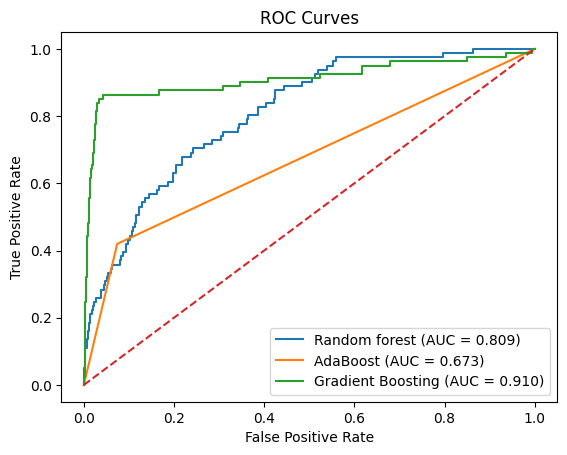

In [40]:
rf_proba = rf_model.predict_proba(X_test)[:, 1]
ada_proba = ada_model.predict_proba(X_test)[:, 1]
gb_proba = gb_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_clf_test, rf_proba)
fpr_ada, tpr_ada, _ = roc_curve(y_clf_test, ada_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_clf_test, gb_proba)

auc_rf = auc(fpr_rf, tpr_rf)
auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label = f"Random forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_ada, tpr_ada, label = f"AdaBoost (AUC = {auc_ada:.3f})")
plt.plot(fpr_gb, tpr_gb, label = f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()